<a href="https://colab.research.google.com/github/jesusthayna60-gif/custos_de_producao/blob/main/Projeto_Final_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv('y1AQEIpMTR2j7xgr9MH0_Manufacturing Dataset.csv')

In [ ]:
df

,Production ID,Date,Product Type,Machine ID,Shift,Units Produced,Defects,Production Time Hours,Material Cost Per Unit,Labour Cost Per Hour,Energy Consumption kWh,Operator Count,Maintenance Hours,Down time Hours,Production Volume Cubic Meters,Scrap Rate,Rework Hours,Quality Checks Failed,Average Temperature C,Average Humidity Percent
0,1899-12-31,2020-01-01,Automotive,3,Swing,142,3.0,23.42,38.68,15.38,413.97,1,4.86,1.57,2.34,0.048,1.65,1,22.8,47.2
1,1900-01-01,2020-01-02,Textiles,8,Night,170,4.0,7.51,21.35,25.36,181.16,2,2.51,0.18,1.52,0.030,NaN,1,23.8,37.9
2,1900-01-02,2020-01-03,Appliances,11,Swing,182,4.0,20.58,47.54,16.46,452.15,2,0.34,2.88,0.57,0.026,0.26,0,24.5,56.1
3,1900-01-03,2020-01-04,Appliances,11,Day,133,NaN,21.68,40.21,28.70,485.78,3,4.64,2.23,1.90,0.036,NaN,2,22.3,50.8
4,1900-01-04,2020-01-05,Electronics,14,Night,82,NaN,16.68,38.02,17.20,315.58,1,2.29,0.02,2.25,0.020,0.67,0,23.4,53.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,1908-03-14,2028-03-14,Automotive,3,Swing,194,7.0,20.74,16.91,15.94,215.04,4,3.06,2.28,1.03,0.021,0.51,1,21.6,53.6
2996,1908-03-15,2028-03-15,Electronics,13,Swing,119,4.0,14.77,34.50,25.95,291.65,2,2.27,0.80,2.09,0.016,1.22,2,24.2,50.9
2997,2998,2028-03-16,Appliances,9,Day,170,2.0,20.38,33.02,18.61,313.24,1,4.66,1.86,1.41,0.047,0.19,0,24.2,51.4
2998,2999,2028-03-17,Furniture,20,Swing,199,3.0,1.01,24.35,29.73,245.47,3,2.73,0.26,0.93,0.029,1.26,1,24.9,56.3


In [ ]:
df.head()

,Production ID,Date,Product Type,Machine ID,Shift,Units Produced,Defects,Production Time Hours,Material Cost Per Unit,Labour Cost Per Hour,Energy Consumption kWh,Operator Count,Maintenance Hours,Down time Hours,Production Volume Cubic Meters,Scrap Rate,Rework Hours,Quality Checks Failed,Average Temperature C,Average Humidity Percent
0,1899-12-31,2020-01-01,Automotive,3,Swing,142,3.0,23.42,38.68,15.38,413.97,1,4.86,1.57,2.34,0.048,1.65,1,22.8,47.2
1,1900-01-01,2020-01-02,Textiles,8,Night,170,4.0,7.51,21.35,25.36,181.16,2,2.51,0.18,1.52,0.030,NaN,1,23.8,37.9
2,1900-01-02,2020-01-03,Appliances,11,Swing,182,4.0,20.58,47.54,16.46,452.15,2,0.34,2.88,0.57,0.026,0.26,0,24.5,56.1
3,1900-01-03,2020-01-04,Appliances,11,Day,133,NaN,21.68,40.21,28.70,485.78,3,4.64,2.23,1.90,0.036,NaN,2,22.3,50.8
4,1900-01-04,2020-01-05,Electronics,14,Night,82,NaN,16.68,38.02,17.20,315.58,1,2.29,0.02,2.25,0.020,0.67,0,23.4,53.9


In [ ]:
'''Cada linha do arquivo CSV representa um único registro de produção, um ciclo de produção descrito pelos dados: ID da Produção, Data, Tipo do Produto, ID da Máquina, Turno'''

'Cada linha do arquivo CSV representa um único registro de produção, um ciclo de produção descrito pelos dados: ID da Produção, Data, Tipo do Produto, ID da Máquina, Turno'

In [ ]:
df.columns

Index(['Production ID', 'Date', 'Product Type', 'Machine ID', 'Shift',
       'Units Produced', 'Defects', 'Production Time Hours',
       'Material Cost Per Unit', 'Labour Cost Per Hour',
       'Energy Consumption kWh', 'Operator Count', 'Maintenance Hours',
       'Down time Hours', 'Production Volume Cubic Meters', 'Scrap Rate',
       'Rework Hours', 'Quality Checks Failed', 'Average Temperature C',
       'Average Humidity Percent'],
      dtype='object')

In [ ]:
#Calculo de Custos totais de acordo com os dados de produção.
df['Custo Material'] = df['Material Cost Per Unit'] * df['Units Produced']
df['Custo de Mão de Obra'] = df['Labour Cost Per Hour'] * df['Production Time Hours']

#Para calcular o valor da Energia tivemos que adotar um valor para o kWh. Disponível no site: https://clarke.com.br/mapa-de-tarifas-de-energia-no-brasil/#principal
valor_por_kWh = 0.82
df['Custo de Energia'] = df['Energy Consumption kWh'] * valor_por_kWh

df['Custo Total'] = df['Custo Material'] + df['Custo de Mão de Obra'] + df['Custo de Energia']
df['Custo Total']

# O próximo passo é calcular o preço/unidade, para termos um parâmetro padronizado para compações e posteriormente relacionar com outros dados.

df['Custo por Unidade'] = df['Custo Total'] / df['Units Produced']

colunas_custo = ['Date','Custo Material',
                 'Custo de Mão de Obra',
                 'Custo de Energia',
                 'Custo Total',
                 'Custo por Unidade']
df[colunas_custo].head()

,Date,Custo Material,Custo de Mão de Obra,Custo de Energia,Custo Total,Custo por Unidade
0,2020-01-01,5492.56,360.1996,339.4554,6192.2150,43.607148
1,2020-01-02,3629.50,190.4536,148.5512,3968.5048,23.344146
2,2020-01-03,8652.28,338.7468,370.7630,9361.7898,51.438405
3,2020-01-04,5347.93,622.2160,398.3396,6368.4856,47.883350
4,2020-01-05,3117.64,286.8960,258.7756,3663.3116,44.674532


In [ ]:
# Cálculo do custo médio por unidade de cada tipo de produto
custo_medio_por_unidade_produto = df.groupby('Product Type')['Custo por Unidade'].mean()
print("Custo Médio por Unidade (R$/Unidade) por Tipo de Produto")
print(round(custo_medio_por_unidade_produto,3))

Custo Médio por Unidade (R$/Unidade) por Tipo de Produto
Product Type
Appliances     34.597
Automotive     34.839
Electronics    35.982
Furniture      36.275
Textiles       34.020
Name: Custo por Unidade, dtype: float64


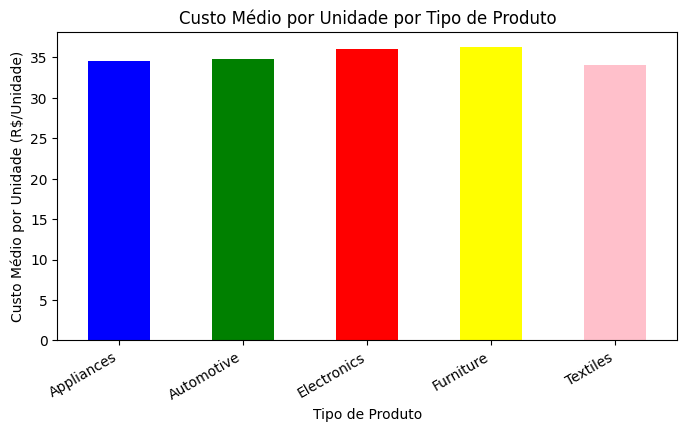

In [ ]:
# Gráfico do Custo médio por unidade versus o tipo de produto
plt.figure(figsize=(8, 4))
colors = ['blue', 'green', 'red', 'yellow', 'pink']
custo_medio_por_unidade_produto.plot(kind='bar', color=colors)
plt.title('Custo Médio por Unidade por Tipo de Produto')
plt.xlabel('Tipo de Produto')
plt.ylabel('Custo Médio por Unidade (R$/Unidade)')
plt.xticks(rotation=30, ha='right')
plt.show()

In [ ]:
# Observamos que os valores médios de produção de cada tipo de produto são proximos.
# Não parece tão relevante uma comparação entre eles.
# Vamos analizar a influência de cada custo.

custo_total_material = df['Custo Material'].sum()
custo_total_labour = df['Custo de Mão de Obra'].sum()
custo_total_energy = df['Custo de Energia'].sum()

custo_total_absoluto = df['Custo Total'].sum()
print('O custo total da indústria é R$', round(custo_total_absoluto,2))

# Calculo de porcentagens:
custo_total_material_percent = (custo_total_material / custo_total_absoluto) * 100
custo_total_labour_percent = (custo_total_labour / custo_total_absoluto) * 100
custo_total_energy_percent = (custo_total_energy / custo_total_absoluto) * 100

#Exibição dos resultados
print('A porcentagem do custo de material é de: ', round(custo_total_material_percent, 2), '%')
print('A porcentagem do custo de mão de obra é de: ', round(custo_total_labour_percent,2), '%')
print('A porcentagem do custo de energia é de: ', round(custo_total_energy_percent,2), '%')

O custo total da indústria é R$ 12924988.11
A porcentagem do custo de material é de:  87.68 %
A porcentagem do custo de mão de obra é de:  6.61 %
A porcentagem do custo de energia é de:  5.71 %


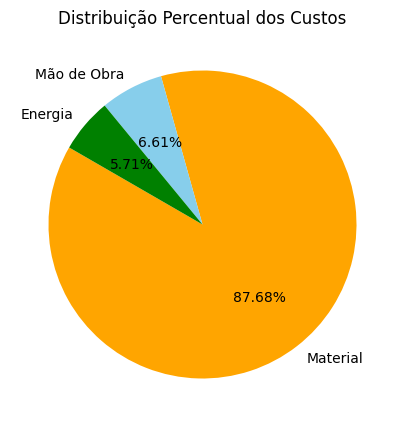

In [ ]:
# Dados para o gráfico de pizza relacionando os tipos de custos da indústria
labels = ['Material', 'Mão de Obra', 'Energia']
custos_porcentagens = [custo_total_material_percent,
         custo_total_labour_percent,
         custo_total_energy_percent]
colors = ['orange', 'skyblue', 'green']

plt.figure(figsize=(10, 5))
plt.pie(custos_porcentagens, labels=labels, colors=colors, autopct='%1.2f%%', startangle=150)
plt.title('Distribuição Percentual dos Custos')
plt.show()

In [22]:
# Vamos analisar a eficiência de cada turno atarvés dos custos
# Custo médio por unidade para cada combinação de produto e turno
custo_por_produto_turno = df.groupby(['Product Type', 'Shift'])['Custo por Unidade'].mean()
print("Custo Médio por Unidade (R$/Unidade) por Tipo de Produto e Turno")
print(round(custo_por_produto_turno, 3))

Custo Médio por Unidade (R$/Unidade) por Tipo de Produto e Turno
Product Type  Shift
Appliances    Day      34.684
              Night    35.093
              Swing    34.009
Automotive    Day      34.647
              Night    34.053
              Swing    35.795
Electronics   Day      36.390
              Night    36.520
              Swing    34.996
Furniture     Day      36.394
              Night    36.418
              Swing    36.018
Textiles      Day      33.877
              Night    34.484
              Swing    33.671
Name: Custo por Unidade, dtype: float64


<Figure size 1200x600 with 0 Axes>

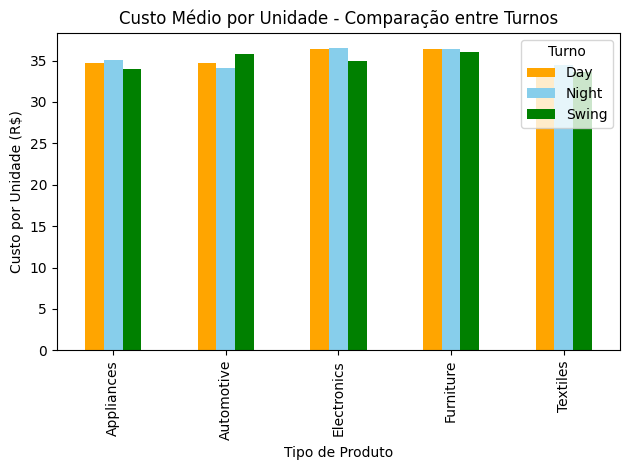

In [33]:
# Gráfico de barras simples
plt.figure(figsize=(12, 6))

# Plotar gráfico de barras
pivot_data.plot(kind='bar', color=['orange', 'skyblue', 'green'])

plt.title('Custo Médio por Unidade - Comparação entre Turnos')
plt.ylabel('Custo por Unidade (R$)')
plt.xlabel('Tipo de Produto')
plt.legend(title='Turno')

plt.tight_layout()
plt.show()

In [37]:
# Encontrar o turno com menor custo para cada produto
turno_mais_eficiente = custo_por_produto_turno.loc[
    custo_por_produto_turno.groupby('Product Type')['Custo por Unidade'].idxmin()
]

print("TURNO MAIS EFICIENTE POR PRODUTO:")
print("=" * 50)
for _, row in turno_mais_eficiente.iterrows():
    print(f"{row['Product Type']:12} → {row['Shift']:6} (R$ {row['Custo por Unidade']:,.3f})")

TURNO MAIS EFICIENTE POR PRODUTO:
Appliances   → Swing  (R$ 34.009)
Automotive   → Night  (R$ 34.053)
Electronics  → Swing  (R$ 34.996)
Furniture    → Swing  (R$ 36.018)
Textiles     → Swing  (R$ 33.671)


In [21]:
''' Observando o gráfico chegamos as seguintes conclusões:
* O swing é o turno mais eficiente em 4 dos 5 produtos
* Night tem a maior variação: melhor em Automotive, mas pior nos demais
* Day é consistentemente intermediário  '''

# Para melhor visualização vamos calcular a média dos custos de produção por turno e comparar graficamente
media_por_turno = df.groupby('Shift')['Custo por Unidade'].mean().reset_index()
print(media_por_turno)

   Shift  Custo por Unidade
0    Day          35.203662
1  Night          35.256506
2  Swing          34.884550


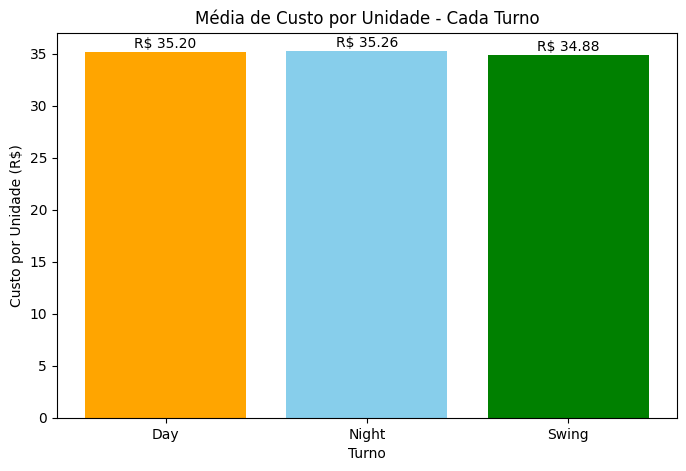

In [38]:
# Calcular a média de custo por unidade para cada turno
media_por_turno = df.groupby('Shift')['Custo por Unidade'].mean()

# Gráfico de barras simples
plt.figure(figsize=(8, 5))

# Cores para cada turno
cores = ['orange', 'skyblue', 'green']

# Criar o gráfico de barras
barras = plt.bar(media_por_turno.index, media_por_turno.values, color=cores)

plt.title('Média de Custo por Unidade - Cada Turno')
plt.ylabel('Custo por Unidade (R$)')
plt.xlabel('Turno')

# Adicionar os valores em cima das barras
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, altura + 0.1,
             f'R$ {altura:.2f}', ha='center', va='bottom')

plt.show()

In [45]:
# =========================================================================
# Vamos analisar o motivo do swing ser o turno com a menor média de custo
# =========================================================================
print("ANÁLISE DE PRODUTIVIDADE POR TURNO:")
print("=" * 40)

# Calcular produtividade (unidades por hora)
df['Produtividade'] = df['Units Produced'] / df['Production Time Hours']
produtividade = df.groupby('Shift')['Produtividade'].mean()

# Calcular velocidade média de produção
df['Velocidade_Producao'] = df['Production Time Hours'] / df['Units Produced']
velocidade = df.groupby('Shift')['Velocidade_Producao'].mean()

print("Produtividade (Unidades/Hora):")
for turno in produtividade.index:
    print(f"{turno}: {produtividade[turno]:.2f} unidades/hora")

print("\nTempo por Unidade (Horas/Unidade):")
for turno in velocidade.index:
    print(f"{turno}: {velocidade[turno]:.3f} horas/unidade")



ANÁLISE DE PRODUTIVIDADE POR TURNO:
Produtividade (Unidades/Hora):
Day: 17.34 unidades/hora
Night: 17.26 unidades/hora
Swing: 17.58 unidades/hora

Tempo por Unidade (Horas/Unidade):
Day: 0.117 horas/unidade
Night: 0.117 horas/unidade
Swing: 0.114 horas/unidade


In [46]:

print("ANÁLISE DE RECURSOS POR TURNO:")
print("=" * 40)

# Calcular custos por unidade para cada componente
df['Custo_Material_Unidade'] = df['Custo Material'] / df['Units Produced']
df['Custo_Mao_Obra_Unidade'] = df['Custo de Mão de Obra'] / df['Units Produced']
df['Custo_Energia_Unidade'] = df['Custo de Energia'] / df['Units Produced']

recursos = df.groupby('Shift').agg({
    'Custo_Material_Unidade': 'mean',
    'Custo_Mao_Obra_Unidade': 'mean',
    'Custo_Energia_Unidade': 'mean',
    'Operator Count': 'mean',
    'Energy Consumption kWh': 'mean'
}).round(3)

print("Custos por Unidade e Recursos:")
print(recursos)

# Verificar eficiência no uso de energia
df['Eficiencia_Energia'] = df['Units Produced'] / df['Energy Consumption kWh']
eficiencia_energia = df.groupby('Shift')['Eficiencia_Energia'].mean()

print("\nEficiência Energética (Unidades/kWh):")
for turno, eficiencia in eficiencia_energia.items():
    print(f"{turno}: {eficiencia:.2f} unidades por kWh")

ANÁLISE DE RECURSOS POR TURNO:
Custos por Unidade e Recursos:
       Custo_Material_Unidade  Custo_Mao_Obra_Unidade  Custo_Energia_Unidade  \
Shift                                                                          
Day                    30.235                   2.693                  2.276   
Night                  30.292                   2.644                  2.321   
Swing                  30.093                   2.563                  2.229   

       Operator Count  Energy Consumption kWh  
Shift                                          
Day             2.493                 298.904  
Night           2.488                 302.866  
Swing           2.504                 297.890  

Eficiência Energética (Unidades/kWh):
Day: 0.50 unidades por kWh
Night: 0.49 unidades por kWh
Swing: 0.51 unidades por kWh


In [48]:
''' Observando os resultados chegamos as seguintes conclusões:
* O Swing é o turno mais eficiente em todos os aspectos

* Economia de R$ 0,32 por unidade vs Day e R$ 0,37 vs Night

* 1,4% mais produtivo que o Day e 1,8% mais que o Night

* Produtividade: Swing (17,58) > Day (17,34) > Night (17,26)

* Custo Material: Swing (R$ 30,093) < Day (R$ 30,235) < Night (R$ 30,292)

* Custo Mão de Obra: Swing (R$ 2,563) < Night (R$ 2,644) < Day (R$ 2,693)

* Eficiência Energética: Swing (0,51) > Day (0,50) > Night (0,49)

A partir desses resulados vamos fazer um programa de melhoria para os turnos day e night'''


' Observando os resultados chegamos as seguintes conclusões:\nO Swing é o turno mais eficiente em todos os aspectos\nEconomia de R$ 0,32 por unidade vs Day e R$ 0,37 vs Night\n1,4% mais produtivo que o Day e 1,8% mais que o Night\nProdutividade: Swing (17,58) > Day (17,34) > Night (17,26)\n\nCusto Material: Swing (R$ 30,093) < Day (R$ 30,235) < Night (R$ 30,292)\n\nCusto Mão de Obra: Swing (R$ 2,563) < Night (R$ 2,644) < Day (R$ 2,693)\n\nEficiência Energética: Swing (0,51) > Day (0,50) > Night (0,49) '

In [53]:
# Dados atuais de cada turno
print("=== COMPARAÇÃO ENTRE TURNOS ===")
print("Swing (o melhor turno):")
print("- Produz 17.58 unidades por hora")
print("- Gasta R$ 30.093 em material por unidade")
print("- Gasta R$ 2.563 em mão de obra por unidade")
print("- Gasta R$ 2.229 em energia por unidade")

print("\nDay (precisa melhorar):")
print("- Produz 17.34 unidades por hora")
print("- Gasta R$ 30.235 em material por unidade")
print("- Gasta R$ 2.693 em mão de obra por unidade")
print("- Gasta R$ 2.276 em energia por unidade")

print("\nNight (precisa melhorar):")
print("- Produz 17.26 unidades por hora")
print("- Gasta R$ 30.292 em material por unidade")
print("- Gasta R$ 2.644 em mão de obra por unidade")
print("- Gasta R$ 2.321 em energia por unidade")

# Calculando quanto cada turno precisa melhorar
print("\n=== QUANTO MELHORAR ===")
print("Day precisa:")
print("- Produzir +0.24 unidades por hora")
print("- Economizar R$ 0.142 em material por unidade")
print("- Economizar R$ 0.130 em mão de obra por unidade")
print("- Economizar R$ 0.047 em energia por unidade")

print("\nNight precisa:")
print("- Produzir +0.32 unidades por hora")
print("- Economizar R$ 0.199 em material por unidade")
print("- Economizar R$ 0.081 em mão de obra por unidade")
print("- Economizar R$ 0.092 em energia por unidade")

# Dicas simples de melhoria
print("\n=== DICAS PARA MELHORAR ===")
print("Para Day (foco em mão de obra):")
print("1. Estudar como o Swing organiza as tarefas")
print("2. Reduzir tempo entre uma tarefa e outra")
print("3. Melhorar a comunicação entre operadores")

print("\nPara Night (foco em material):")
print("1. Verificar como o Swing usa o material")
print("2. Reduzir desperdício e retrabalho")
print("3. Melhorar a iluminação para ver melhor")


# Calculadora simples de economia
print("\n=== ECONOMIA POTENCIAL ===")
producao = 500  # unidades por dia
dias = 22       # dias no mês

# Day
economia_day = (0.142 + 0.130 + 0.047) * producao * dias
print(f"Day pode economizar R$ {economia_day:.2f} por mês")

# Night
economia_night = (0.199 + 0.081 + 0.092) * producao * dias
print(f"Night pode economizar R$ {economia_night:.2f} por mês")

print(f"\nJuntos podem economizar R$ {economia_day + economia_night:.2f} por mês!")

=== COMPARAÇÃO ENTRE TURNOS ===
Swing (o melhor turno):
- Produz 17.58 unidades por hora
- Gasta R$ 30.093 em material por unidade
- Gasta R$ 2.563 em mão de obra por unidade
- Gasta R$ 2.229 em energia por unidade

Day (precisa melhorar):
- Produz 17.34 unidades por hora
- Gasta R$ 30.235 em material por unidade
- Gasta R$ 2.693 em mão de obra por unidade
- Gasta R$ 2.276 em energia por unidade

Night (precisa melhorar):
- Produz 17.26 unidades por hora
- Gasta R$ 30.292 em material por unidade
- Gasta R$ 2.644 em mão de obra por unidade
- Gasta R$ 2.321 em energia por unidade

=== QUANTO MELHORAR ===
Day precisa:
- Produzir +0.24 unidades por hora
- Economizar R$ 0.142 em material por unidade
- Economizar R$ 0.130 em mão de obra por unidade
- Economizar R$ 0.047 em energia por unidade

Night precisa:
- Produzir +0.32 unidades por hora
- Economizar R$ 0.199 em material por unidade
- Economizar R$ 0.081 em mão de obra por unidade
- Economizar R$ 0.092 em energia por unidade

=== DICAS 